In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

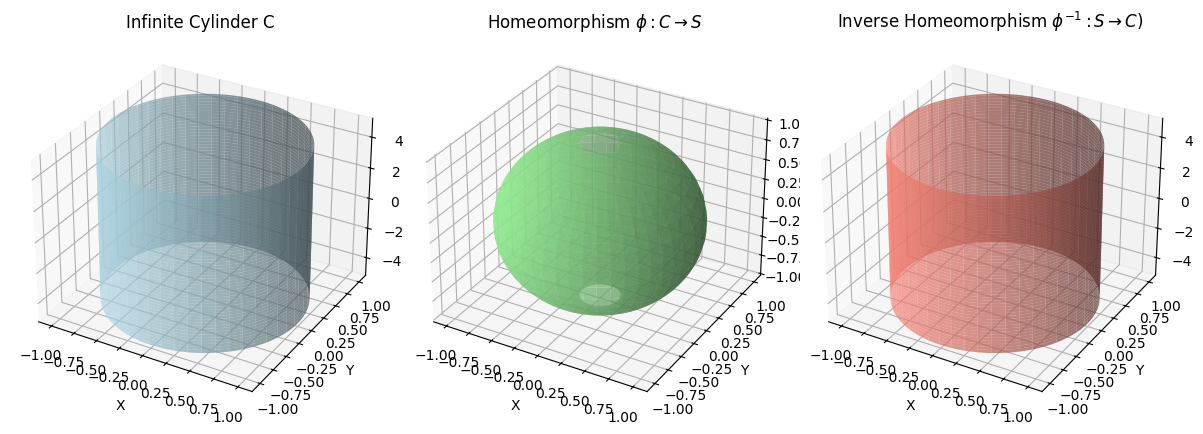

In [9]:
# Parametrize the infinite cylinder C
theta = np.linspace(0, 2 * np.pi, 100)  # Angle around the cylinder
z_cylinder = np.linspace(-5, 5, 100)  # Height along the cylinder
theta, z_cylinder = np.meshgrid(theta, z_cylinder)
x_cylinder = np.cos(theta)  # x = cos(theta)
y_cylinder = np.sin(theta)  # y = sin(theta)

# Define the homeomorphism h: C -> S
def homeomorphism(x, y, z):
    scale = np.sqrt(1 + z**2)
    x_sphere = x / scale
    y_sphere = y / scale
    z_sphere = z / scale
    return x_sphere, y_sphere, z_sphere
# Define the inverse homeomorphism h^(-1): S -> C
def inverse_homeomorphism(x, y, z):
    scale = 1 / np.sqrt(1 - z**2)  # Inverse of the scale factor
    x_cylinder = x * scale
    y_cylinder = y * scale
    z_cylinder = z * scale
    return x_cylinder, y_cylinder, z_cylinder

# Generate points on the twice punctured sphere S
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(-0.99, 0.99, 100)  # Avoid poles at -1 and 1
u, v = np.meshgrid(u, v)
x_sphere = np.cos(u) * np.sqrt(1 - v**2)
y_sphere = np.sin(u) * np.sqrt(1 - v**2)
z_sphere = v


# Apply the homeomorphism to each point on the cylinder
x_sphere, y_sphere, z_sphere = homeomorphism(x_cylinder, y_cylinder, z_cylinder)
x_cylinder_inv, y_cylinder_inv, z_cylinder_inv = inverse_homeomorphism(x_sphere, y_sphere, z_sphere)

# Create a 3D plot
fig = plt.figure(figsize=(12, 6))

# Plot the infinite cylinder C
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(x_cylinder, y_cylinder, z_cylinder, color='lightblue', alpha=0.7)
ax1.set_title("Infinite Cylinder C")
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')

# Plot the twice punctured sphere S
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(x_sphere, y_sphere, z_sphere, color='lightgreen', alpha=0.7)
ax2.set_title(r"Homeomorphism $\phi:C \to S$")
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')

# Plot the inverse homeomorphism (cylinder from sphere)
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(x_cylinder_inv, y_cylinder_inv, z_cylinder_inv, color='salmon', alpha=0.7)
ax3.set_title(r"Inverse Homeomorphism $\phi^{-1}:S\to C$)")
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('Z')

# Adjust the layout to accommodate the new subplot
plt.tight_layout()

plt.show()

